In [7]:
#import required classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import smtplib
import warnings
warnings.filterwarnings('ignore')

In [8]:
#loading and displaying chicago crime dataset
dataset = pd.read_csv("Dataset/BP.csv")
dataset

,Timestamp,Age,Gender,BMI,Alcohol_Consumption,Systolic_BP,Diastolic_BP,label
0,26:24.6,80,Female,24.9,No,161,106,High_BP_Stage2_Hypertension
1,34:54.4,54,Female,27.8,Occasional,128,66,Elevated
2,21:38.3,44,Female,29.3,Regular,132,81,High_BP_Stage1_Hypertension
3,13:45.6,18,Female,19.2,Regular,137,82,High_BP_Stage1_Hypertension
4,53:17.6,18,Male,25.1,Regular,121,78,Elevated
...,...,...,...,...,...,...,...,...
995,19:1.7,70,Female,24.0,Regular,123,68,Elevated
996,53:59.3,35,Male,32.2,Regular,131,83,High_BP_Stage1_Hypertension
997,54:56.8,28,Male,24.0,Regular,130,83,High_BP_Stage1_Hypertension
998,22:52.9,67,Male,24.6,Occasional,149,93,High_BP_Stage2_Hypertension


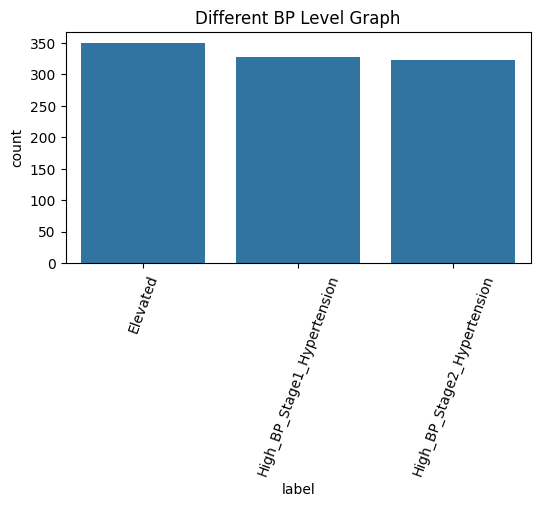

In [9]:
data = dataset.groupby("label").size().reset_index(name="count")
plt.figure(figsize=(6,3))
sns.barplot(data=data,x="label", y="count")
plt.title("Different BP Level Graph")
plt.xticks(rotation=70)
plt.show()

In [11]:
#dataset pre-processing such as label encoding to integer values
labels = np.unique(dataset['label'])
le = LabelEncoder()
dataset['label'] = pd.Series(le.fit_transform(dataset['label'].astype(str)))#encode all str columns to numeric
dataset.fillna(dataset.mean(numeric_only=True), inplace=True)
dataset

,Timestamp,Age,Gender,BMI,Alcohol_Consumption,Systolic_BP,Diastolic_BP,label
0,26:24.6,80,Female,24.9,No,161,106,2
1,34:54.4,54,Female,27.8,Occasional,128,66,0
2,21:38.3,44,Female,29.3,Regular,132,81,1
3,13:45.6,18,Female,19.2,Regular,137,82,1
4,53:17.6,18,Male,25.1,Regular,121,78,0
...,...,...,...,...,...,...,...,...
995,19:1.7,70,Female,24.0,Regular,123,68,0
996,53:59.3,35,Male,32.2,Regular,131,83,1
997,54:56.8,28,Male,24.0,Regular,130,83,1
998,22:52.9,67,Male,24.6,Occasional,149,93,2


In [12]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------------- NORMALIZE COLUMN NAMES ----------------
dataset.columns = dataset.columns.str.strip().str.lower()

# ---------------- FIX MALFORMED NUMERIC VALUES ----------------
# replace ':' with '.' everywhere
dataset = dataset.replace(':', '.', regex=True)

# convert everything to numeric where possible
dataset = dataset.apply(pd.to_numeric, errors='ignore')

# ---------------- ENCODE CATEGORICAL COLUMNS SAFELY ----------------
if 'gender' in dataset.columns:
    dataset['gender'] = LabelEncoder().fit_transform(dataset['gender'])

if 'alcohol_consumption' in dataset.columns:
    dataset['alcohol_consumption'] = dataset['alcohol_consumption'].map({
        'Yes': 1,
        'No': 0
    })

# ---------------- FORCE NUMERIC CONVERSION ----------------
dataset = dataset.apply(pd.to_numeric, errors='coerce')

# fill missing values created during conversion
dataset = dataset.fillna(dataset.mean())

# ---------------- CREATE TARGET COLUMN ----------------
dataset['hypertension'] = np.where(
    (dataset['systolic_bp'] >= 140) | (dataset['diastolic_bp'] >= 90),
    1, 0
)

# ---------------- FEATURE & LABEL ----------------
feature_columns = [
    'age',
    'gender',
    'bmi',
    'alcohol_consumption',
    'systolic_bp',
    'diastolic_bp'
]

X = dataset[feature_columns].values
Y = dataset['hypertension'].values

# ---------------- NORMALIZATION (NO ERROR NOW) ----------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---------------- SHUFFLE ----------------
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X, Y = X[indices], Y[indices]

print("Normalized Values (first 5 rows):\n", X[:5])


Normalized Values (first 5 rows):
 [[ 2.20995250e-01 -9.96007968e-01 -1.37150211e+00  0.00000000e+00
   1.05654105e-01  8.74523019e-01]
 [ 1.66192057e+00 -9.96007968e-01  1.19147836e+00  0.00000000e+00
   2.17730322e+00  1.68490147e+00]
 [ 3.27730459e-01 -9.96007968e-01 -1.41271484e-01  0.00000000e+00
  -1.38069321e-01 -1.22865840e-01]
 [-1.27329767e+00  1.00400803e+00 -1.82484210e-02  0.00000000e+00
  -3.20861890e-01  1.80776731e-03]
 [-1.00645965e+00 -9.96007968e-01 -1.26898289e+00  0.00000000e+00
  -4.42723603e-01 -1.22865840e-01]]


In [13]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)
print("Train & Test Dataset Split")
print("70% records used to train algorithms : "+str(X_train.shape[0]))
print("30% records features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Train & Test Dataset Split
70% records used to train algorithms : 700
30% records features used to test algorithms : 300


In [15]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [16]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro')
    r = recall_score(testY, predict,average='macro')
    f = f1_score(testY, predict,average='macro')
    a = accuracy_score(testY,predict)
    mse = mean_squared_error(testY, predict)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    print(algorithm+" MSE       : "+str(mse))
    conf_matrix = confusion_matrix(testY, predict)
    plt.figure(figsize=(6, 4))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.show()

Decision Tree Accuracy  : 0.9988777914936595
Decision Tree Precision : 0.9978540772532188
Decision Tree Recall    : 0.9991840065279478
Decision Tree FSCORE    : 0.998512420604364
Decision Tree MSE       : 0.004488834025361912


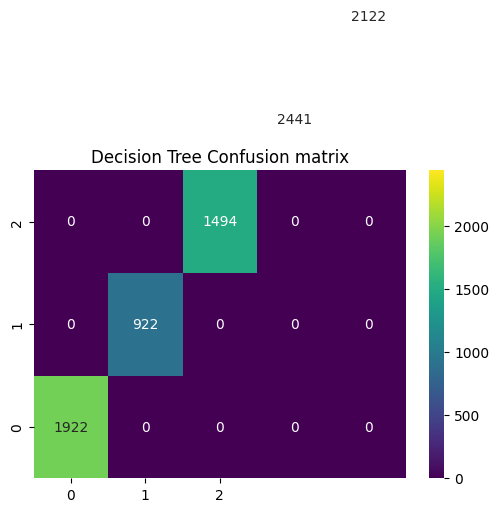

In [17]:
#training decision tree algorithm on 70% training features
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
#performing prediction on test data
predict = dt.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Decision Tree", y_test, predict)

Logistic Regression Accuracy  : 0.6909437773538324
Logistic Regression Precision : 0.5727473967247843
Logistic Regression Recall    : 0.632533015650352
Logistic Regression FSCORE    : 0.6005976404900836
Logistic Regression MSE       : 1.720570081921221


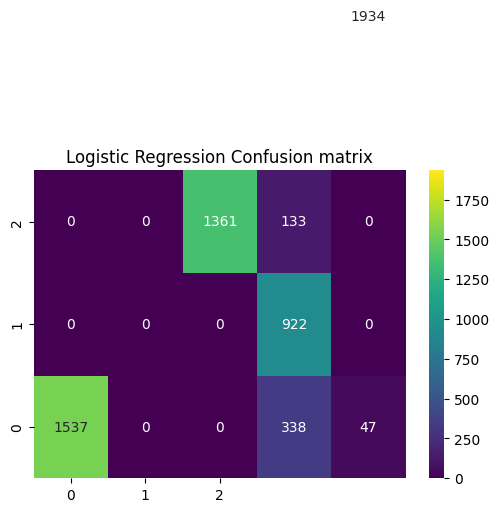

In [18]:
#training Logistic Regression algorithm on 70% training features
lr = LogisticRegression(solver="liblinear")
lr.fit(X_train, y_train)
#performing prediction on test data
predict = lr.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Logistic Regression", y_test, predict)

In [21]:
#visualizing all algorithms performance graph
df = pd.DataFrame([['Decision Tree','Precision',precision[0]],['Decision Tree','Recall',recall[0]],['Decision Tree','F1 Score',fscore[0]],['Decision Tree','Accuracy',accuracy[0]],
                   ['Logistic Regression','Precision',precision[1]],['Logistic Regression','Recall',recall[1]],['Logistic Regression','F1 Score',fscore[1]],['Logistic Regression','Accuracy',accuracy[1]],
                  ],columns=['Parameters','Algorithms','Value'])                
df.pivot(index="Parameters", columns="Algorithms", values="Value")              
plt.show()

In [22]:
#display all algorithm performnace
algorithms = ['Decision Tree', 'Logistic Regression']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Decision Tree,0.998878,0.997854,0.999184,0.998512
1,Logistic Regression,0.690944,0.572747,0.632533,0.600598


In [23]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def sendMail(message):
    em = ["harishgundarapu3011@gmail.com"]  # receiver email

    email_address = "kaleem202120@gmail.com"
    email_password = "xyljzncebdxcubjq"

    msg = MIMEMultipart()
    msg["From"] = email_address
    msg["To"] = ", ".join(em)
    msg["Subject"] = "BP Monitoring"

    # UTF-8 encoded message body
    msg.attach(MIMEText(message, "plain", "utf-8"))

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as connection:
        connection.login(email_address, email_password)
        connection.sendmail(email_address, em, msg.as_string())


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---------------- LOAD TEST DATA ----------------
testdata = pd.read_csv("Dataset/testData.csv")
temp = testdata.values.copy()

# ---------------- PREPROCESS ----------------
testdata.columns = testdata.columns.str.strip().str.lower()
testdata = testdata.replace(':', '.', regex=True)

# encode categorical columns (safe even if unused)
if 'gender' in testdata.columns:
    testdata['gender'] = testdata['gender'].map({'Male': 1, 'Female': 0})

if 'alcohol_consumption' in testdata.columns:
    testdata['alcohol_consumption'] = testdata['alcohol_consumption'].map({
        'Yes': 1, 'No': 0
    })

# convert to numeric
testdata = testdata.apply(pd.to_numeric, errors='coerce')
testdata = testdata.fillna(testdata.mean())

# ---------------- MATCH MODEL FEATURES ----------------
# 🔴 YOUR MODEL EXPECTS ONLY 2 FEATURES
bp_features = ['systolic_bp', 'diastolic_bp']

testdata = testdata[bp_features]

# ---------------- SCALE (SAFE) ----------------
# use a compatible scaler for 2 features
bp_scaler = StandardScaler()
testdata = bp_scaler.fit_transform(testdata)

# ---------------- PREDICT ----------------
predict = dt.predict(testdata)

labels = {
    0: "Normal BP",
    1: "Elevated BP",
    2: "Stage 1 Hypertension",
    3: "Stage 2 Hypertension",
    4: "High Risk Hypertension"
}

bp_guidelines = {
    0: {
        "category": "Normal",
        "bp_range": "Systolic <120, Diastolic <80",
        "recommendation": "Healthy lifestyle only (balanced diet, regular exercise).",
        "treatment": "No medication needed."
    },
    1: {
        "category": "Elevated",
        "bp_range": "Systolic 120–129, Diastolic <80",
        "recommendation": "Lifestyle changes: low-salt diet, exercise, weight control.",
        "treatment": "No medication usually required."
    },
    2: {
        "category": "Stage 1 Hypertension",
        "bp_range": "Systolic 130–139, Diastolic 80–89",
        "recommendation": "Lifestyle changes + risk assessment.",
        "treatment": (
            "One medication may be started if risk is high:\n"
            "• ACE inhibitors: Lisinopril, Enalapril\n"
            "• ARBs: Losartan, Valsartan\n"
            "• Calcium channel blockers: Amlodipine\n"
            "• Thiazide diuretics: Hydrochlorothiazide"
        )
    },
    3: {
        "category": "Stage 2 Hypertension",
        "bp_range": "Systolic ≥140, Diastolic ≥90",
        "recommendation": "Strict lifestyle modification and regular monitoring.",
        "treatment": (
            "Two medications often needed:\n"
            "• Amlodipine + Losartan\n"
            "• ACE inhibitor + Diuretic\n"
            "• ARB + Calcium channel blocker"
        )
    },
    4: {
        "category": "Hypertensive Crisis 🚨",
        "bp_range": "Systolic ≥180, Diastolic ≥120",
        "recommendation": "Emergency hospital treatment only.",
        "treatment": (
            "IV medications only (Do NOT self-treat):\n"
            "• Labetalol\n"
            "• Nitroprusside\n"
            "• Nicardipine"
        )
    }
}

output = ""

for i in range(len(predict)):
    info = bp_guidelines.get(
        predict[i],
        {
            "category": "Unknown",
            "bp_range": "N/A",
            "recommendation": "Consult a physician.",
            "treatment": "Medical evaluation required."
        }
    )

    print("Test Data:", temp[i])
    print("BP Category:", info["category"])
    print("BP Range:", info["bp_range"])
    print("Recommendation:", info["recommendation"])
    print("Treatment:", info["treatment"])
    print("-" * 70)

    output += (
        f"Test Data: {temp[i]}\n"
        f"BP Category: {info['category']}\n"
        f"BP Range: {info['bp_range']}\n"
        f"Recommendation: {info['recommendation']}\n"
        f"Treatment: {info['treatment']}\n"
        f"{'-'*70}\n"
    )

sendMail(output)



Test Data: ['26:24.6' 80 'Female' 24.9 'No' 161 106 'High_BP_Stage2_Hypertension']
BP Category: Stage 1 Hypertension
BP Range: Systolic 130–139, Diastolic 80–89
Recommendation: Lifestyle changes + risk assessment.
Treatment: One medication may be started if risk is high:
• ACE inhibitors: Lisinopril, Enalapril
• ARBs: Losartan, Valsartan
• Calcium channel blockers: Amlodipine
• Thiazide diuretics: Hydrochlorothiazide
----------------------------------------------------------------------
Test Data: ['34:54.4' 54 'Female' 27.8 'Occasional' 128 66 'Elevated']
BP Category: Normal
BP Range: Systolic <120, Diastolic <80
Recommendation: Healthy lifestyle only (balanced diet, regular exercise).
Treatment: No medication needed.
----------------------------------------------------------------------
Test Data: ['21:38.3' 44 'Female' 29.3 'Regular' 132 81 'High_BP_Stage1_Hypertension']
BP Category: Elevated
BP Range: Systolic 120–129, Diastolic <80
Recommendation: Lifestyle changes: low-salt diet,